# Autoregressive Model for Explicit Density Estimation

In this approach, we model the likelihood directly, making the computation tractable by leveraging the chain rule to decompose the probability of a pixel $x_i$ into a conditional probability. The context for $x_i$ is provided by the preceding pixels. This conditional information is captured by a recurrent neural network (RNN) through its hidden state, which is passed forward in the sequence. The hidden state then serves as the context for predicting the next pixel value.

The probability of the data can be expressed as:
$$
p(x) = \prod_{i=1}^n p\left(x_i \mid x_1, \ldots, x_{i-1}\right)
$$

To reduce computational demands, I reformulated the problem as a sequence prediction task. Instead of using $(n \times m)$ images as instances, I generated sinusoidal patterns represented as vectors. These vectors have values constrained between 0 and 255 and a sequnce length of 16, simplifying the input space while maintaining the structure necessary for autoregressive modeling. Therefore instead of PixelRNN we are training a vanilla Long short-term memory (LSTM). These models are similar to RNNs but protect the integrity of the hidden state making the model more sensitive to long time series data. In this notebook you will complete code for a Dataset class, LSTM autoregressive class, and a training function. You can inspect your models performance visually simply by feeding the trained model and data instances into the given plotting function.

In [1]:
# Importing the libraries
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from torch.utils.data import DataLoader, Dataset

In [6]:
# Generate sinusoidal data
def create_sinusoidal_dataset(num_samples=1000, vector_length=16, frequency=2):
    x = np.linspace(0, 2 * np.pi * frequency, vector_length)
    data = np.zeros((num_samples, vector_length), dtype=np.uint8)
    for i in range(num_samples):
        amplitude = np.random.uniform(50, 100)
        phase = np.random.uniform(0, 2 * np.pi)
        offset = np.random.uniform(100, 150)
        pattern = amplitude * np.sin(x + phase) + offset
        pattern = np.clip(pattern, 0, 255)
        data[i] = pattern.astype(np.uint8)
    return data

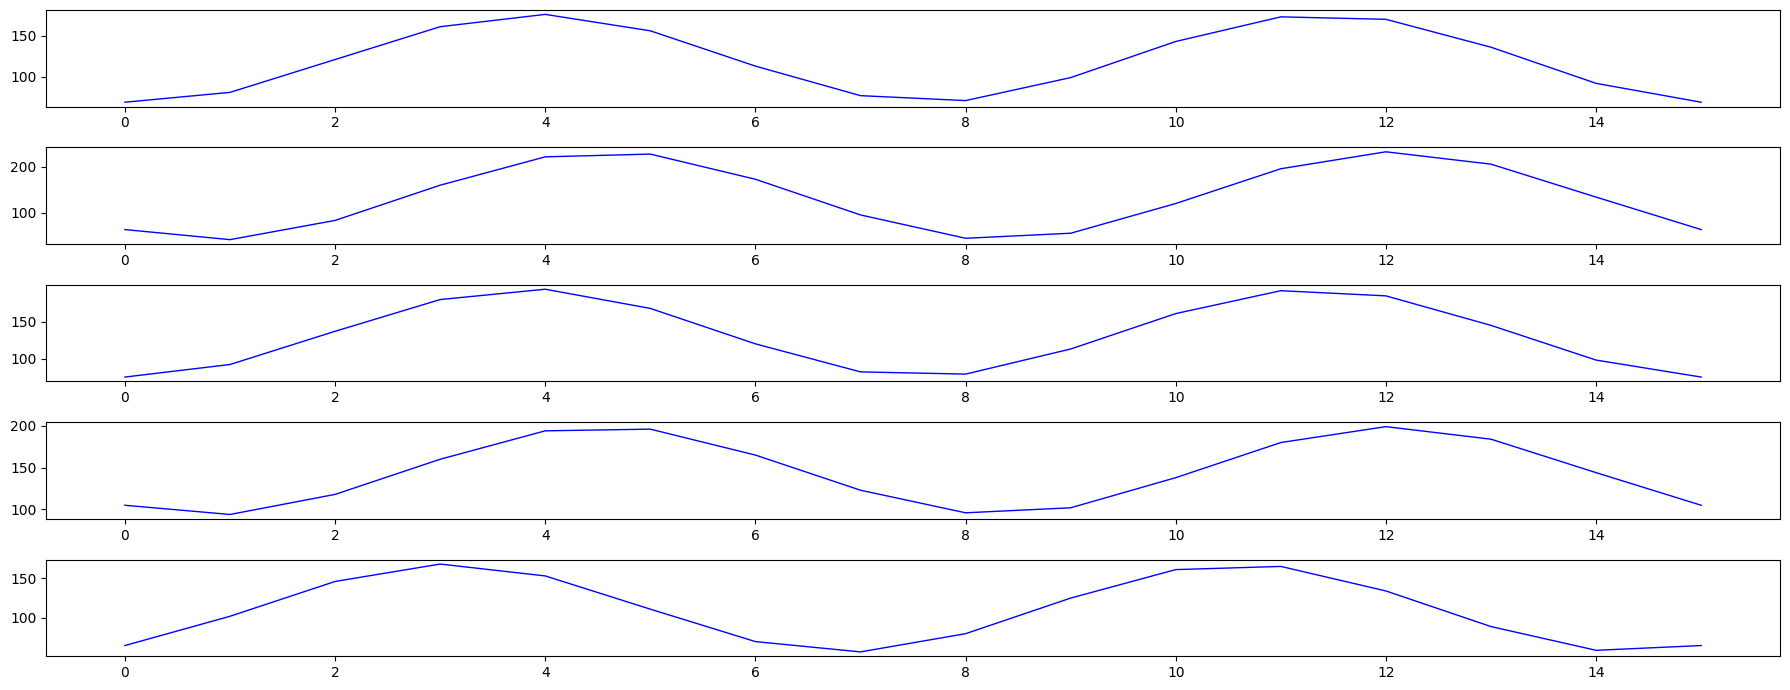

In [4]:
# Plot random samples of the data
data = create_sinusoidal_dataset()
plt.figure(figsize=(18, 7))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(data[i], linewidth=1, color='blue')
plt.tight_layout()
plt.show()

In [5]:
# Create a custom Dataset class that loads the sinusoidal data and returns input-target pairs of type torch.float32
# The is the data generated by the create_sinusoidal_dataset function while the target is the same data shifted by one step
class SinusoidalDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sequence = self.data[index][:-1]  # Input sequence
        target = self.data[index][1:]    # Target sequence (shifted by one step)
        return torch.tensor(sequence, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

In [6]:
# Test your SinusoidalDataset class by running this code block 
# # The block creates a dataset and dataloader using create_sinusoidal_dataset and the SinusoidalDataset class
# The output of the block should print torch.Size([1, 15]) torch.Size([1, 15]), and 15 pairs of input-target sequences offset by one step
data = create_sinusoidal_dataset(1, 16)
train_dataset = SinusoidalDataset(data)
train_loader = DataLoader(train_dataset, batch_size=1)
x, target = next(iter(train_loader))
print(x.shape, target.shape)
for i in range(x.size(1)):
    print(f'Input: {x[0, i].item():.2f} -> Target: {target[0, i].item():.2f}')

torch.Size([1, 15]) torch.Size([1, 15])
Input: 197.00 -> Target: 174.00
Input: 174.00 -> Target: 106.00
Input: 106.00 -> Target: 35.00
Input: 35.00 -> Target: 10.00
Input: 10.00 -> Target: 47.00
Input: 47.00 -> Target: 121.00
Input: 121.00 -> Target: 184.00
Input: 184.00 -> Target: 193.00
Input: 193.00 -> Target: 143.00
Input: 143.00 -> Target: 67.00
Input: 67.00 -> Target: 15.00
Input: 15.00 -> Target: 22.00
Input: 22.00 -> Target: 82.00
Input: 82.00 -> Target: 157.00
Input: 157.00 -> Target: 197.00


In [8]:
# Define the LSTM model
# The model should have an LSTM layer followed by a fully connected layer
# The fully connected layer should output one value at a time (the next value in the sequence)
# Remember to set batch_first=True in the LSTM layer
# And that lstms return two values, the output and the hidden state 
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)  # Predict one value at a time

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

In [8]:
# The code block below tests the LSTMPredictor model by passing a random input tensor of shape (1, 15, 1) through the model
# The output shape should be (1, 15, 1)
model = LSTMPredictor(input_size=1, hidden_size=16, num_layers=1)
out = model(x.unsqueeze(-1)) # model takes input of shape (batch_size, seq_len, input_size)
print(out.shape) # output shape: (batch_size, seq_len, 1) -> (1, 15, 1)

torch.Size([1, 15, 1])


In [ ]:
# Create a function that trains the model
def train_model(model, dataloader, criterion, optimizer, num_epochs, device):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Add extra dimension for single feature input
            inputs = inputs.unsqueeze(-1)
            targets = targets.unsqueeze(-1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(dataloader):.4f}")

In [10]:
# Set Hyperparameters
num_samples = 2000
vector_length = 16
batch_size = 32
input_size = 1
hidden_size = 64
num_layers = 1
num_epochs = 200
learning_rate = 0.001

In [11]:
# Create dataset and DataLoader
data = create_sinusoidal_dataset(num_samples, vector_length)
train_dataset = SinusoidalDataset(data)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model, loss function, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMPredictor(input_size, hidden_size, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
train_model(model, train_loader, criterion, optimizer, num_epochs, device)

Epoch [1/200], Loss: 18242.8590
Epoch [2/200], Loss: 16886.9313
Epoch [3/200], Loss: 15519.5453
Epoch [4/200], Loss: 14348.4100
Epoch [5/200], Loss: 13373.9125
Epoch [6/200], Loss: 12543.7310
Epoch [7/200], Loss: 11781.5255
Epoch [8/200], Loss: 11089.2781
Epoch [9/200], Loss: 10438.3742
Epoch [10/200], Loss: 9847.1802
Epoch [11/200], Loss: 9279.0883
Epoch [12/200], Loss: 8758.5376
Epoch [13/200], Loss: 8280.0036
Epoch [14/200], Loss: 7822.0721
Epoch [15/200], Loss: 7412.1829
Epoch [16/200], Loss: 7021.6911
Epoch [17/200], Loss: 6673.5205
Epoch [18/200], Loss: 6333.4625
Epoch [19/200], Loss: 6014.5753
Epoch [20/200], Loss: 5714.6652
Epoch [21/200], Loss: 5415.9839
Epoch [22/200], Loss: 5132.1697
Epoch [23/200], Loss: 4861.0228
Epoch [24/200], Loss: 4600.8279
Epoch [25/200], Loss: 4340.1994
Epoch [26/200], Loss: 4086.0508
Epoch [27/200], Loss: 3859.9529
Epoch [28/200], Loss: 3642.2201
Epoch [29/200], Loss: 3434.4740
Epoch [30/200], Loss: 3238.0485
Epoch [31/200], Loss: 3051.8774
Epoch [3

In [12]:
# Use function as is to plot predictions and visualy inspect the model
def plot_predictions_with_context_shading(data, model, context_length, num_samples, device, fig_size=(10, 8)):
    """
    Plot original data and model predictions with grid background and shaded context region.

    Parameters:
        data (numpy array): Original dataset.
        model (torch.nn.Module): Trained RNN model.
        context_length (int): Length of context used for prediction.
        num_samples (int): Number of samples to visualize.
        device (torch.device): Device to use for inference.
    """
    model.eval()
    fig, axes = plt.subplots(num_samples, 1, figsize=fig_size, sharex=True)
    if num_samples == 1:
        axes = [axes]
        
    for i in range(num_samples):
        original_sequence = data[i]
        context_sequence = original_sequence[:context_length]
        ground_truth = original_sequence[context_length:]
        
        predictions = []
        with torch.no_grad():
            input_seq = torch.tensor(context_sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
            for _ in range(len(ground_truth)):
                output = model(input_seq)
                next_val = output[:, -1, :].squeeze().cpu().item()
                predictions.append(next_val)
                # Update input sequence with the new prediction
                next_input = torch.tensor([[next_val]], dtype=torch.float32).to(device)
                input_seq = torch.cat((input_seq[:, 1:, :], next_input.unsqueeze(0)), dim=1)

        # Plotting
        ax = axes[i]
        
        # Add grid and shaded context region
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.add_patch(Rectangle((0, ax.get_ylim()[0]), context_length, ax.get_ylim()[1] - ax.get_ylim()[0],
                               color='lightgrey', alpha=0.3, zorder=0))
        
        # Plot ground truth, context, and predictions
        ax.plot(range(len(original_sequence)), original_sequence, label="Ground Truth", color="green")
        ax.plot(range(context_length), context_sequence, label="Context", color="blue")
        ax.scatter(range(context_length, len(original_sequence)), predictions, color="red", label="Predictions")
        
        ax.legend(loc="upper left")
        ax.set_title(f"Sample {i+1}")
        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Value")

    plt.tight_layout()
    plt.show()


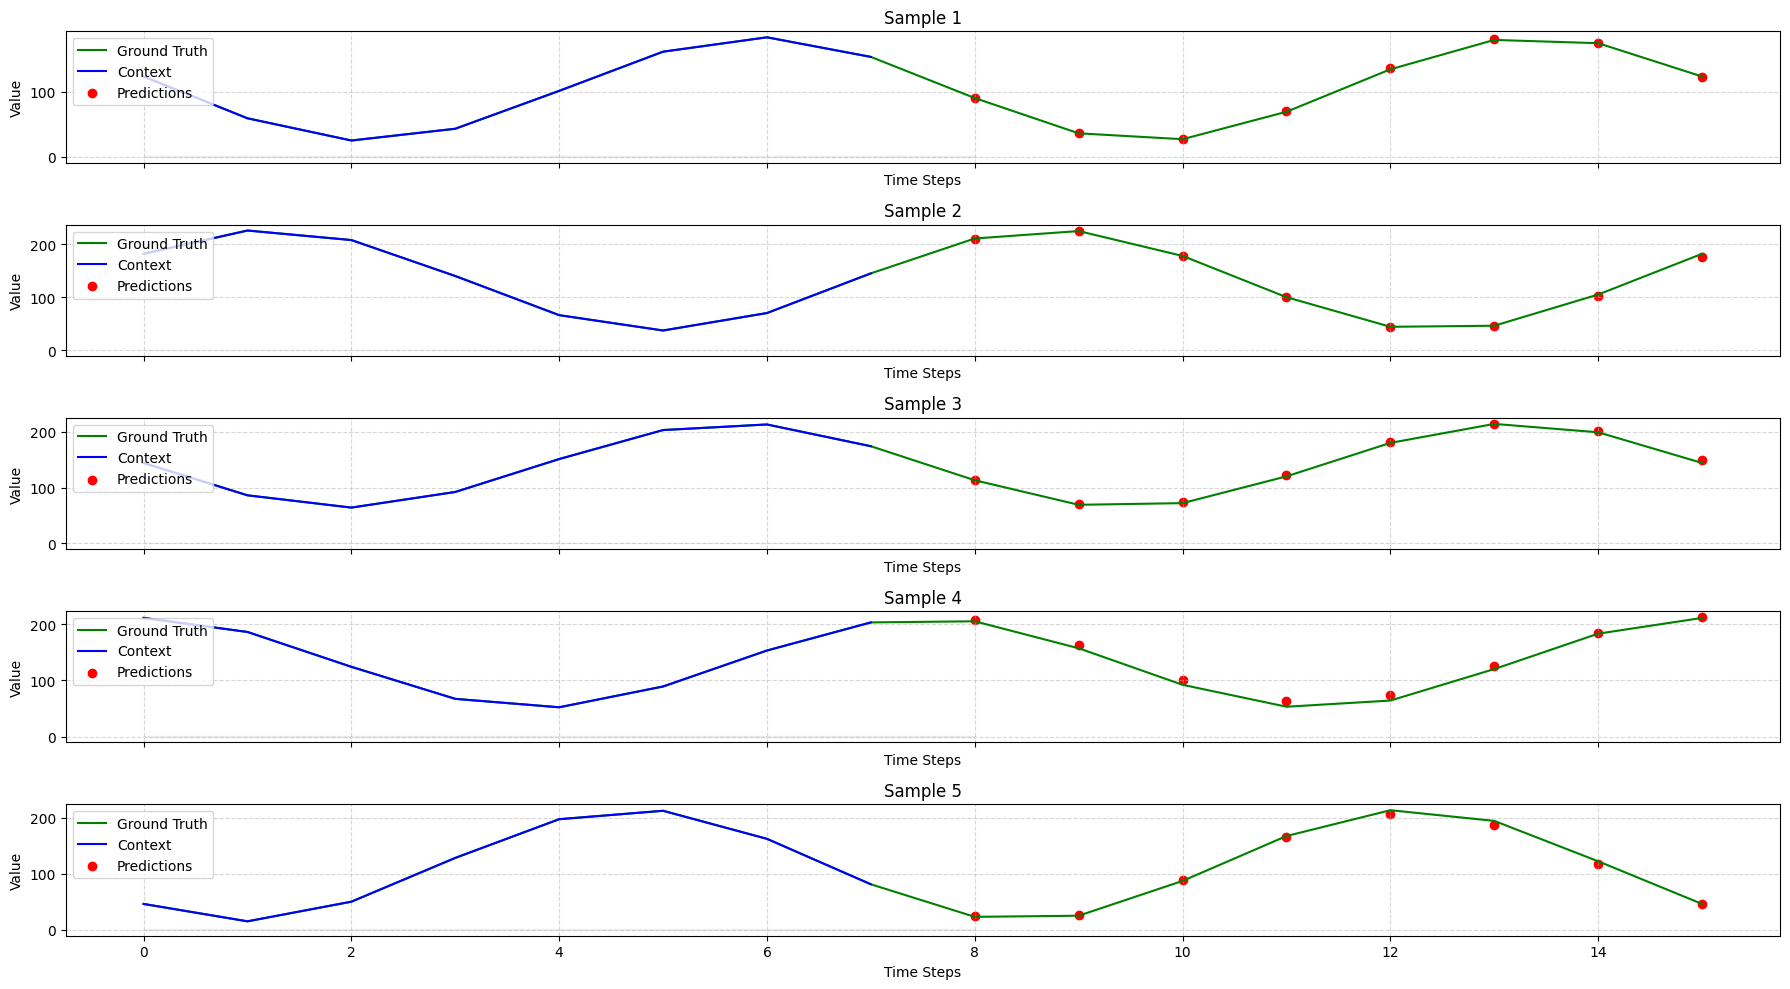

In [13]:
# Evaluate the models performance by plotting predictions
plot_predictions_with_context_shading(data, model, context_length=8, num_samples=5, device=device, fig_size=(18, 10))

In [14]:
# What happens when you decrease the context length. Use the above plot function to make an argument. Explain your observations.

Context Length: 1


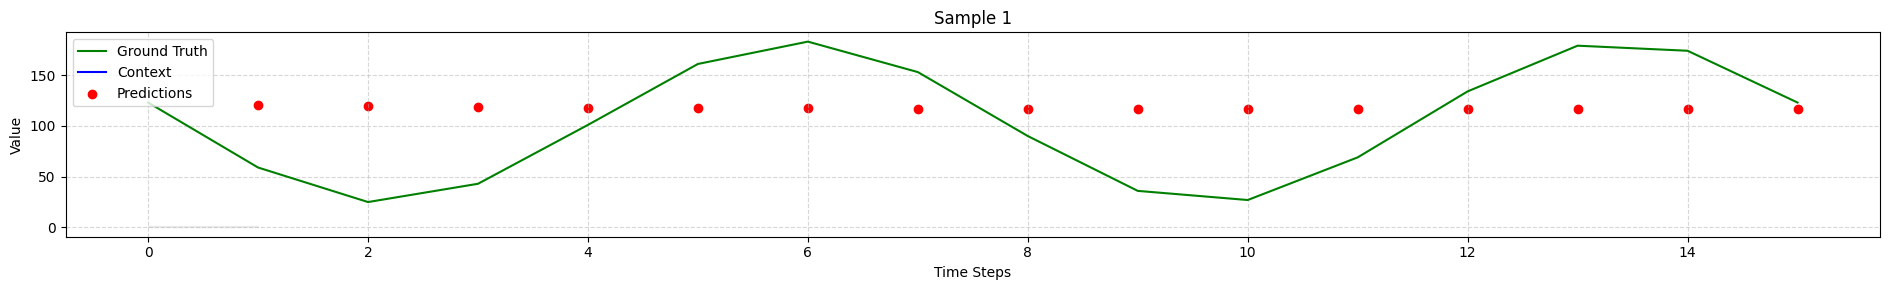

Context Length: 2


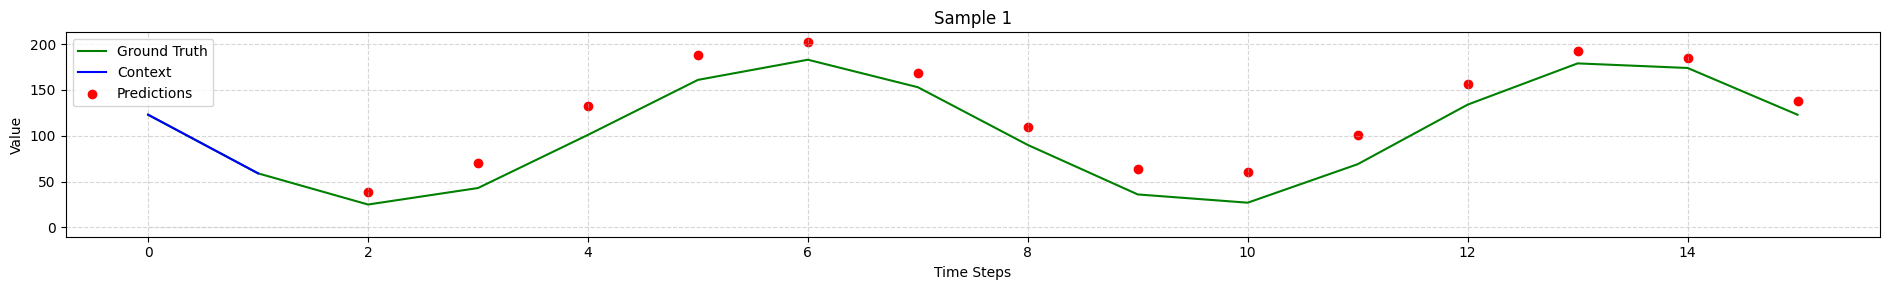

Context Length: 3


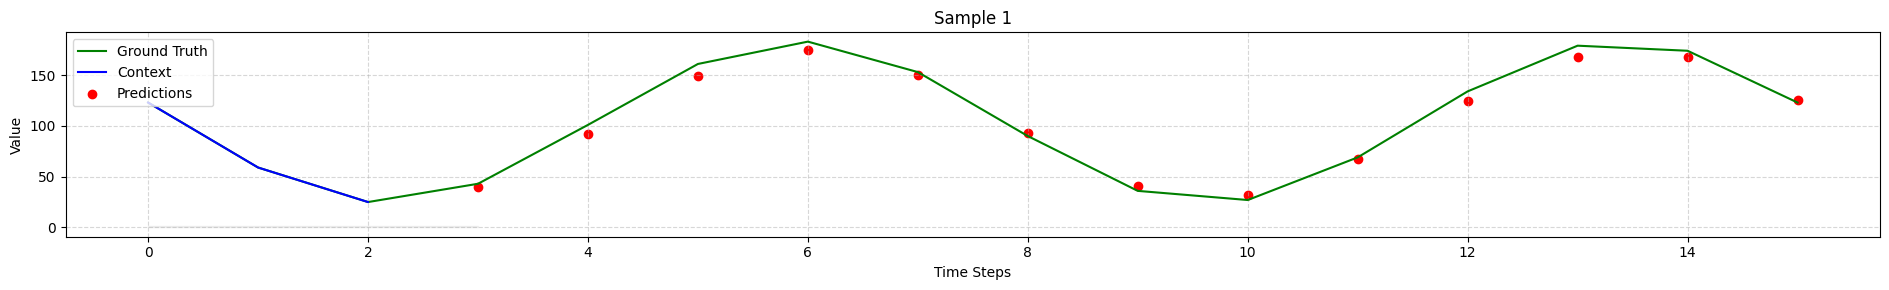

Context Length: 4


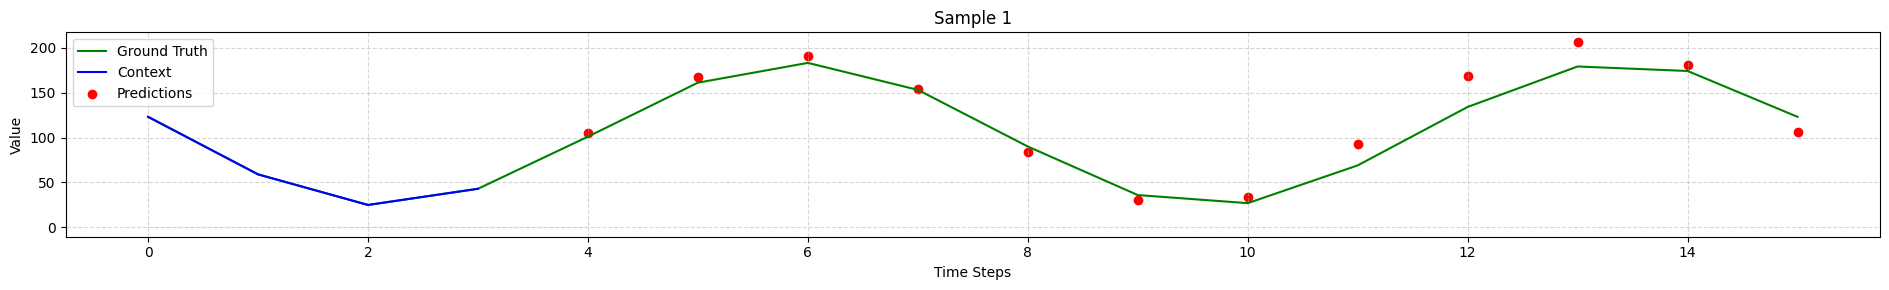

Context Length: 5


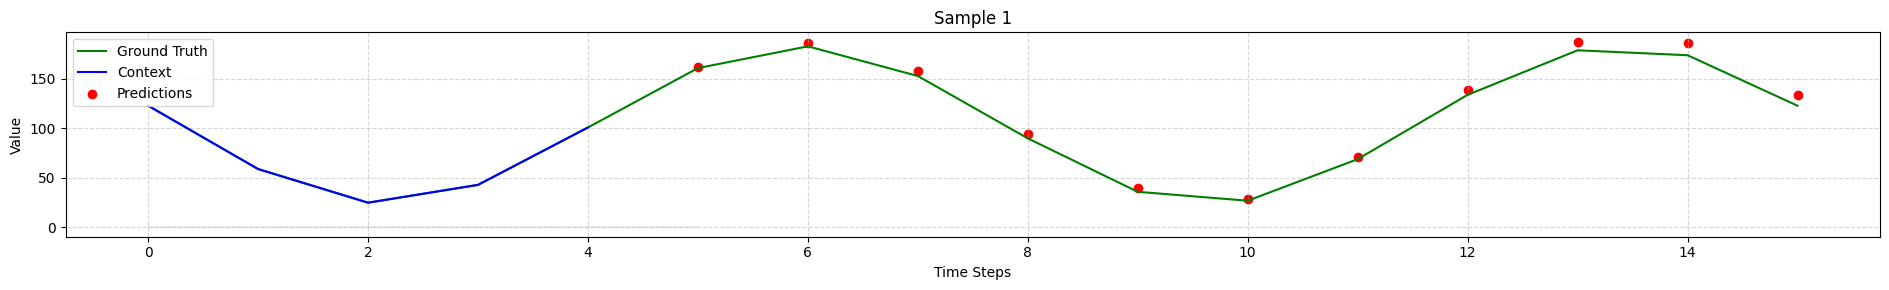

Context Length: 6


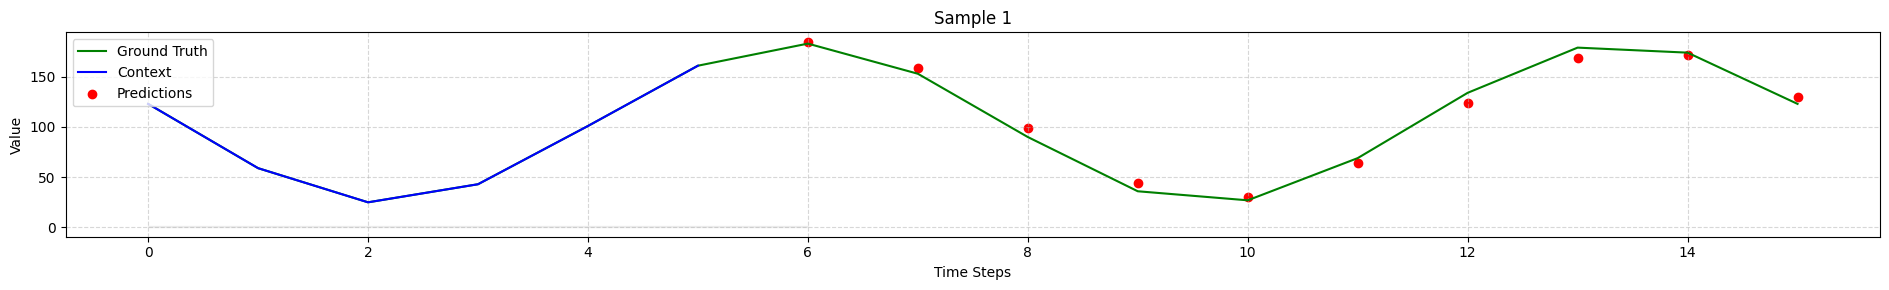

Context Length: 7


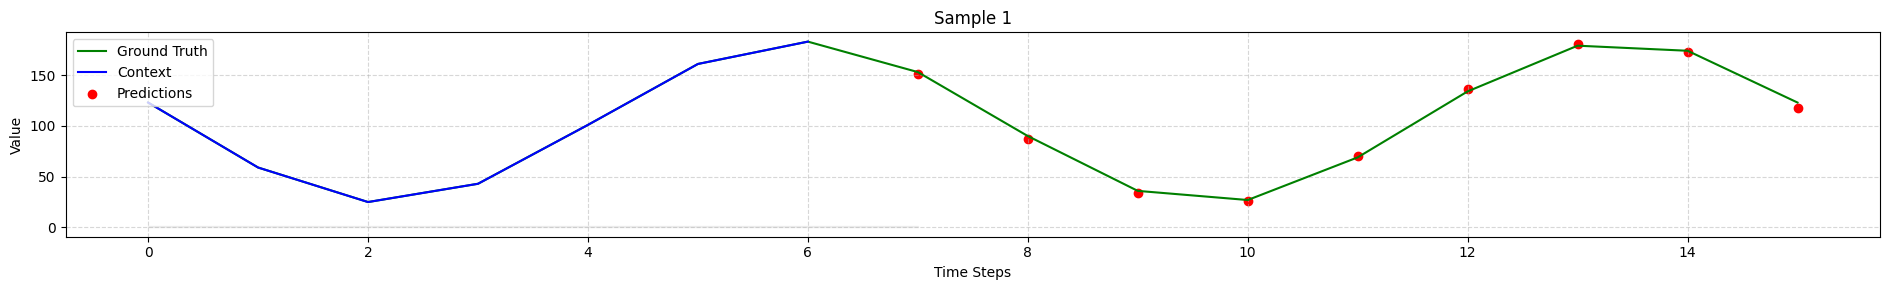

Context Length: 8


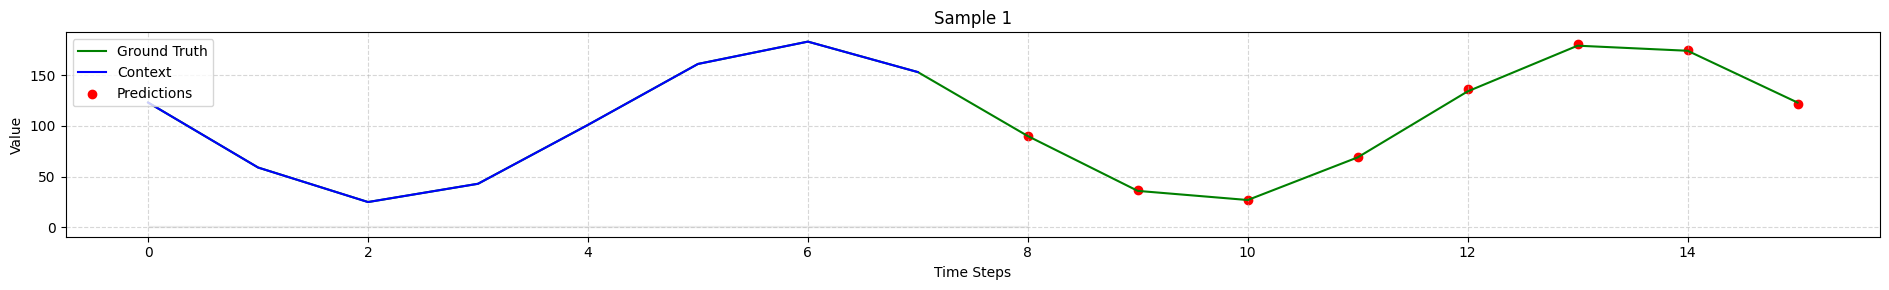

Context Length: 9


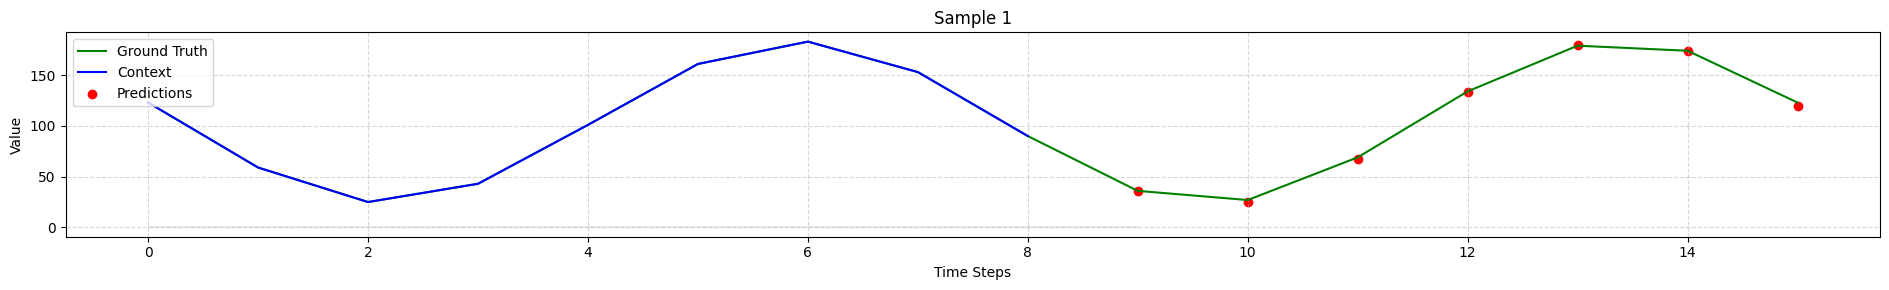

Context Length: 10


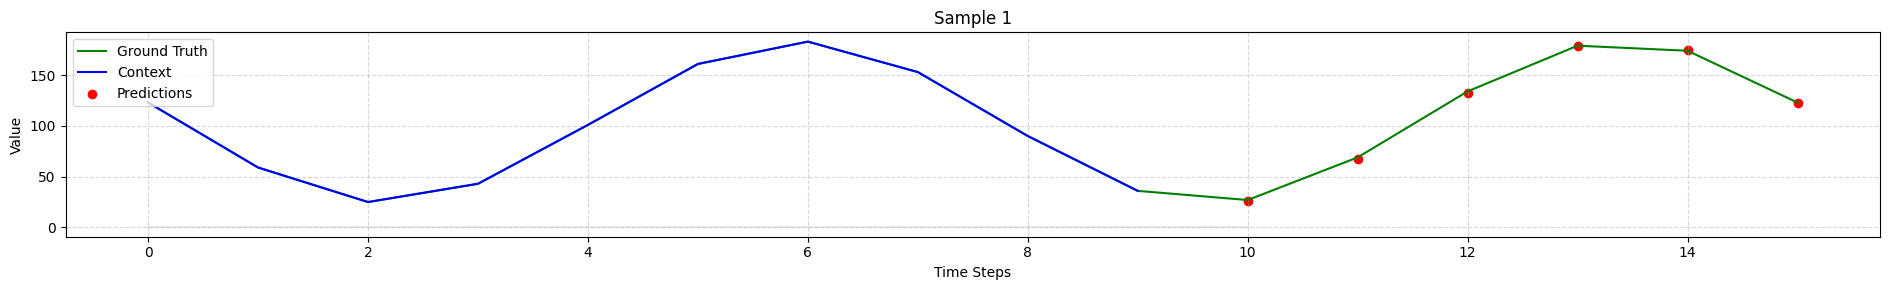

In [15]:
for i in range(1, 11):
    print(f"Context Length: {i}")
    plot_predictions_with_context_shading(data, model, context_length=i, num_samples=1, device=device, fig_size=(19, 3))

In [ ]:
# The model only requres two points to understand the direction and it performs well. More context makes it more accurate. Increasing the models
# Training time and capacity will make it more accurate with less context.

In [15]:
from torch.nn.utils.rnn import pad_sequence

def variable_length_collate(batch):
    # Separate inputs and targets
    inputs = [item[0] for item in batch]  # Variable-length input contexts
    targets = [item[1] for item in batch]  # Corresponding target sequences
    
    # Pad inputs and targets to the same length in the batch
    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0.0)
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=0.0)
    
    return inputs_padded, targets_padded


In [2]:
class VariableContextDataset(Dataset):
    def __init__(self, data, min_context=1):
        self.data = data
        self.min_context = min_context

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sequence = self.data[index]
        sequence_length = len(sequence)
        
        # Randomly sample context length for each sequence
        context_length = np.random.randint(self.min_context, sequence_length)
        
        input_context = sequence[:context_length]  # Variable-length context
        target = sequence[context_length:]  # Target is the remainder of the sequence
        
        return (
            torch.tensor(input_context, dtype=torch.float32), 
            torch.tensor(target, dtype=torch.float32)
        )

In [10]:
def train_variable_context(model, dataloader, criterion, optimizer, num_epochs, device, max_seq_len):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            batch_loss = 0
            
            # Process each sequence individually
            for i in range(inputs.size(0)):  # Loop over batch
                input_context = inputs[i]  # Variable-length input
                target_seq = targets[i]  # Corresponding target sequence

                # Initialize LSTM states
                hidden_state = None  # LSTM will initialize to zero state

                # Process the context and generate predictions step-by-step
                for t in range(len(target_seq)):
                    # Use teacher forcing: ground truth as input for the next step
                    input_step = input_context.unsqueeze(0).unsqueeze(-1)  # (1, seq_len, 1)
                    
                    # Predict next pixel
                    output, hidden_state = model.lstm(input_step, hidden_state)
                    output = model.fc(output[:, -1, :])  # Only take the last timestep
                    
                    # Compute loss for the current prediction
                    loss = criterion(output.squeeze(), target_seq[t])
                    batch_loss += loss
                
                    # Append the current ground truth to input context
                    if t + 1 < len(target_seq):  # If there's a next timestep
                        input_context = torch.cat([input_context, target_seq[t].unsqueeze(0)])
            
            batch_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            epoch_loss += batch_loss.item() / inputs.size(0)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(dataloader):.4f}")

In [11]:
# Set Hyperparameters
num_samples = 2000
vector_length = 16
batch_size = 32
input_size = 1
hidden_size = 64
num_layers = 1
num_epochs = 200
learning_rate = 0.001

In [16]:
# Create dataset and DataLoader
data = create_sinusoidal_dataset(num_samples, vector_length)
train_dataset = VariableContextDataset(data)
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=variable_length_collate  # Use the custom collate function
)

# Initialize model, loss function, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMPredictor(input_size, hidden_size, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
train_variable_context(model, train_loader, criterion, optimizer, num_epochs, device, max_seq_len=12)

Epoch [1/200], Loss: 147335.8695
Epoch [2/200], Loss: 133566.0099
Epoch [3/200], Loss: 121678.7037
Epoch [4/200], Loss: 115507.4681
Epoch [5/200], Loss: 112485.8353
Epoch [6/200], Loss: 108311.3318
Epoch [7/200], Loss: 99910.8163
Epoch [8/200], Loss: 96721.9009
Epoch [9/200], Loss: 88588.9746
Epoch [10/200], Loss: 84095.9027
Epoch [11/200], Loss: 80147.4541
Epoch [12/200], Loss: 75860.2449
Epoch [13/200], Loss: 70427.6762
Epoch [14/200], Loss: 67113.8746
Epoch [15/200], Loss: 63067.8286
Epoch [16/200], Loss: 59917.3129
Epoch [17/200], Loss: 64061.7455
Epoch [18/200], Loss: 69406.2494


KeyboardInterrupt: 